In [3]:
import numpy as np
import pandas as pd
from patsy import dmatrices
from pandas import DataFrame
import statsmodels.api as sm
import pandas.plotting as px

In [5]:

# Seed the pseudo-random number generator
np.random.seed(12)

# Sample size
n=100

# Create data
wcc = np.round(np.random.normal(15, 5, n), 0)
crp = (wcc * 2) + np.round(np.random.normal(0, 10, n), 0)

lipase = wcc + crp + np.round(np.random.normal(2, 10, n), 0)

# Pandas dataframe obejct
df = DataFrame(
    {'WCC':wcc,
     'CRP':crp,
     'Lipase':lipase}
)

Text(0.5, 0.98, 'Scatter plot matrix')

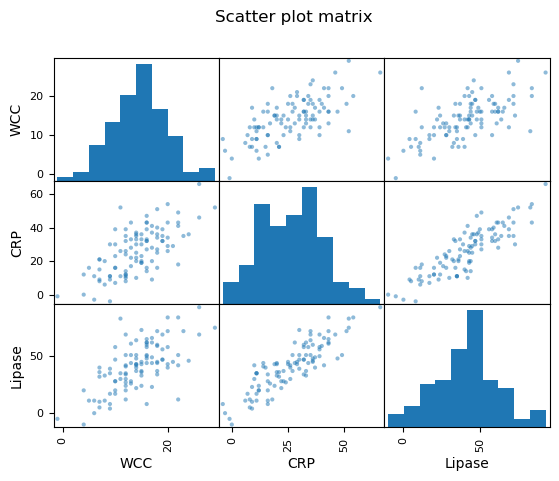

In [8]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

scatter_matrix(df)
plt.suptitle('Scatter plot matrix')  

In [ ]:
# target vector and design matrix
y, X = dmatrices('Lipase ~ WCC + CRP', data=df, return_type='dataframe')   
 



In [12]:
# creat multiple linear regression model with WCC and CRP as predictors of Lipase
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())    


                            OLS Regression Results                            
Dep. Variable:                 Lipase   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     157.3
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           3.61e-31
Time:                        20:37:20   Log-Likelihood:                -374.15
No. Observations:                 100   AIC:                             754.3
Df Residuals:                      97   BIC:                             762.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3741      3.013      0.788      0.4

#### The high F-statistic with an extremely small p-value shows the model is highly statistically significant, meaning WCC and CRP ajointly explain lipase far better than chance. 

#### CRP is a strong and highly significant predictor of Lipase, while WCC is also significant but only marginally, the intercept is not statistically significant (p=0.433)

#### The R squared of 0.764 indicates the model explains about 76.4% of the varation in Lipase, showing a strong overall fit. 